In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

<Figure size 1000x600 with 0 Axes>

In [2]:
df = pd.read_csv(
    "../data/processed/clean_supplement_sales.csv",
    parse_dates=["Order_Date"]
)

df.head()

,Order_ID,Order_Date,Customer_ID,Age,Gender,State,Product_Name,Category,Quantity,Unit_Price,Revenue,Payment_Method,Channel,Customer_Type,Year,Month,Month_Name,Quarter
0,ORD00001,2024-09-27,CUST6191,38,Male,Haryana,Immunity Booster,Immunity,4,649,2596,Debit Card,Flipkart,New,2024,9,September,3
1,ORD00002,2025-10-25,CUST9322,39,Male,Maharashtra,Weight Control Capsules,Weight Management,4,1199,4796,COD,Amazon,New,2025,10,October,4
2,ORD00003,2024-06-09,CUST5555,39,Male,Punjab,Detox Tea,Detox,5,599,2995,UPI,Flipkart,Repeat,2024,6,June,2
3,ORD00004,2025-11-30,CUST1189,20,Male,Karnataka,Hair Serum,Hair Care,4,699,2796,Debit Card,Website,Repeat,2025,11,November,4
4,ORD00005,2025-08-23,CUST9433,26,Female,Bihar,Hair Serum,Hair Care,4,699,2796,Credit Card,Flipkart,Repeat,2025,8,August,3


In [3]:
#total no of sales
total_revenue = df["Revenue"].sum()

print(f"Total Revenue: ₹{total_revenue:,.0f}")

Total Revenue: ₹22,938,386


In [4]:
#total orders
total_orders = df["Order_ID"].nunique()

print(f"Total Orders: {total_orders:,}")


Total Orders: 10,000


In [5]:
#average order value
aov = df["Revenue"].sum() / df["Order_ID"].nunique()

print(f"Average Order Value: ₹{aov:,.2f}")

Average Order Value: ₹2,293.84


In [6]:
#top products
product_revenue = (
    df.groupby("Product_Name")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

product_revenue

Product_Name
Weight Control Capsules    5276799
Hair Capsules              3801871
Skin Glow Tablets          3530781
Hair Serum                 2966556
Immunity Booster           2618715
Detox Tea                  2601457
Hair Oil                   2142207
Name: Revenue, dtype: int64

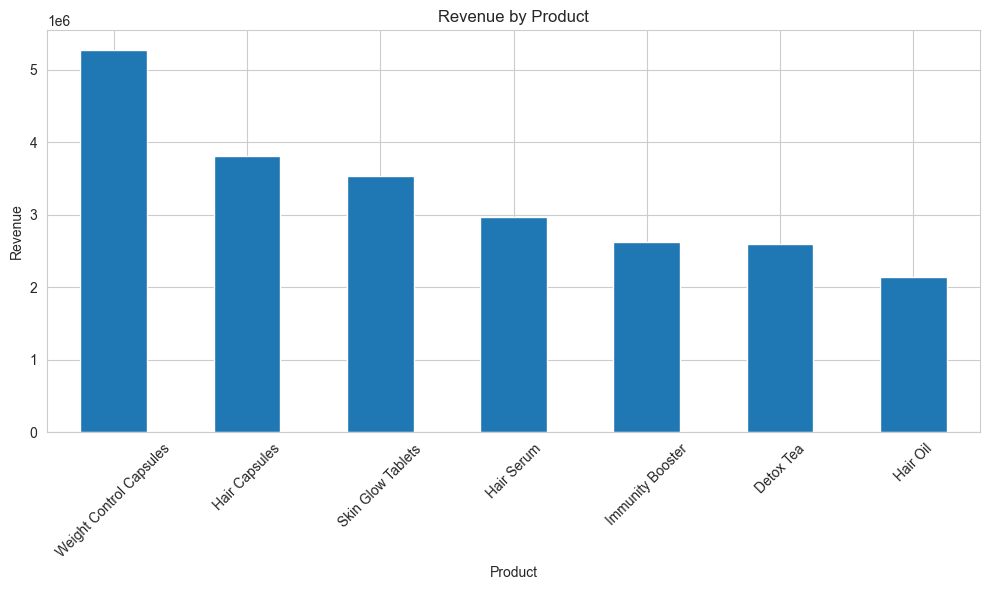

In [7]:
#visualtization
plt.figure(figsize=(10,6))

product_revenue.plot(kind="bar")

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [8]:
#monthly sales
monthly_sales = (
    df.groupby(
        df["Order_Date"].dt.to_period("M")
    )["Revenue"]
    .sum()
)

monthly_sales

Order_Date
2024-01    1026787
2024-02     852119
2024-03    1091531
2024-04    1008578
2024-05     968623
2024-06     917651
2024-07    1008592
2024-08     969424
2024-09     929794
2024-10    1027029
2024-11     922628
2024-12     971406
2025-01     942531
2025-02     908517
2025-03     969168
2025-04     883075
2025-05     978129
2025-06     890427
2025-07    1022775
2025-08     948786
2025-09     842503
2025-10     957353
2025-11    1016979
2025-12     883981
Freq: M, Name: Revenue, dtype: int64

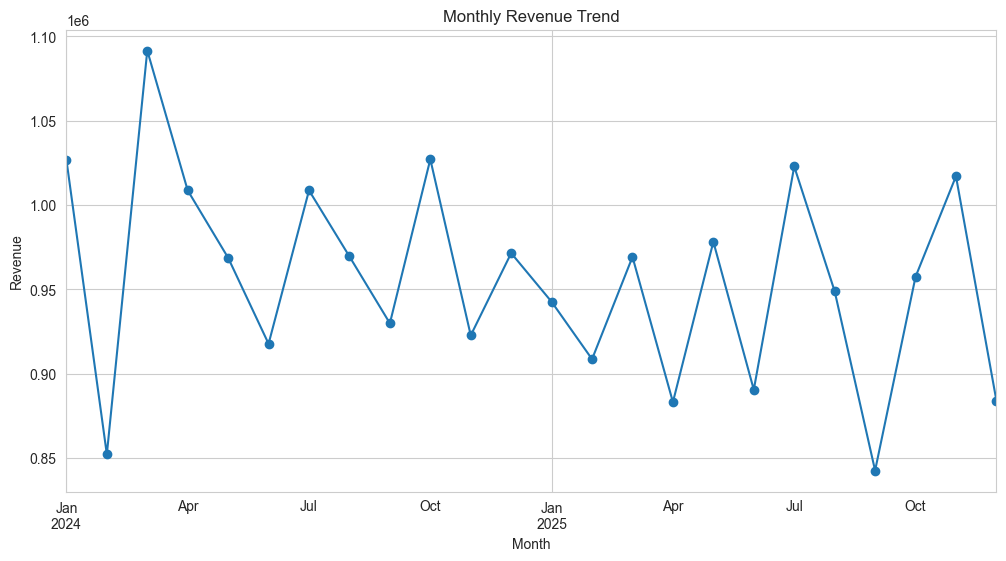

In [9]:
#trend chart
monthly_sales.plot(
    figsize=(12,6),
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

In [10]:
monthly_sales.idxmax(), monthly_sales.max()

(Period('2024-03', 'M'), np.int64(1091531))

In [11]:
monthly_sales.idxmin(), monthly_sales.min()

(Period('2025-09', 'M'), np.int64(842503))

In [12]:
#revenue by states
state_revenue = (
    df.groupby("State")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

state_revenue

State
Haryana          2405760
Gujarat          2391813
Maharashtra      2373014
Bihar            2330286
Karnataka        2289201
Punjab           2272747
West Bengal      2250601
Rajasthan        2232706
Delhi            2202499
Uttar Pradesh    2189759
Name: Revenue, dtype: int64

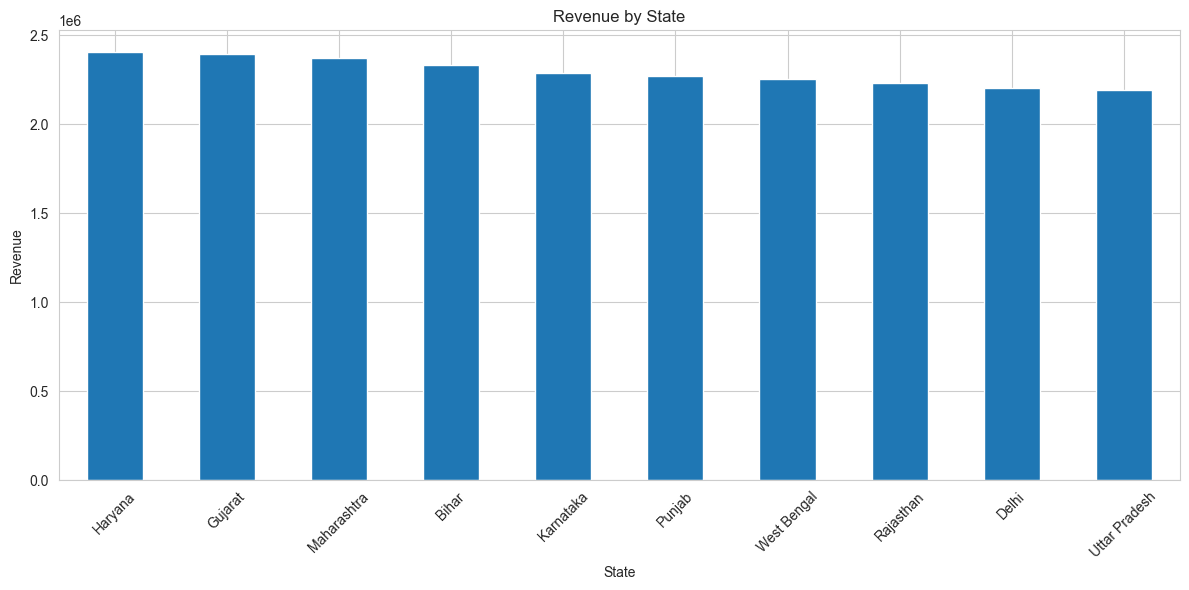

In [13]:
#states chart
plt.figure(figsize=(12,6))

state_revenue.plot(kind="bar")

plt.title("Revenue by State")
plt.xlabel("State")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


In [14]:
state_revenue.idxmax(), state_revenue.max()

('Haryana', np.int64(2405760))

In [15]:
state_revenue.idxmin(), state_revenue.min()

('Uttar Pradesh', np.int64(2189759))

In [16]:
state_orders = (
    df.groupby("State")["Order_ID"]
      .count()
      .sort_values(ascending=False)
)

state_orders

State
Gujarat          1037
Haryana          1033
Bihar            1031
Karnataka         994
Maharashtra       994
Punjab            993
West Bengal       992
Uttar Pradesh     986
Rajasthan         977
Delhi             963
Name: Order_ID, dtype: int64

In [17]:
#custome type distribution
customer_type_counts = (
    df["Customer_Type"]
      .value_counts()
)

customer_type_counts

Customer_Type
Repeat    6024
New       3976
Name: count, dtype: int64

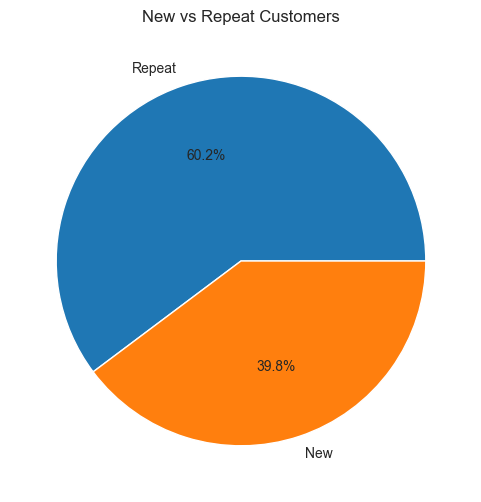

In [18]:
#pie chart
customer_type_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("New vs Repeat Customers")
plt.ylabel("")

plt.show()

In [19]:
customer_revenue = (
    df.groupby("Customer_Type")["Revenue"]
      .sum()
)

customer_revenue

Customer_Type
New        9123440
Repeat    13814946
Name: Revenue, dtype: int64

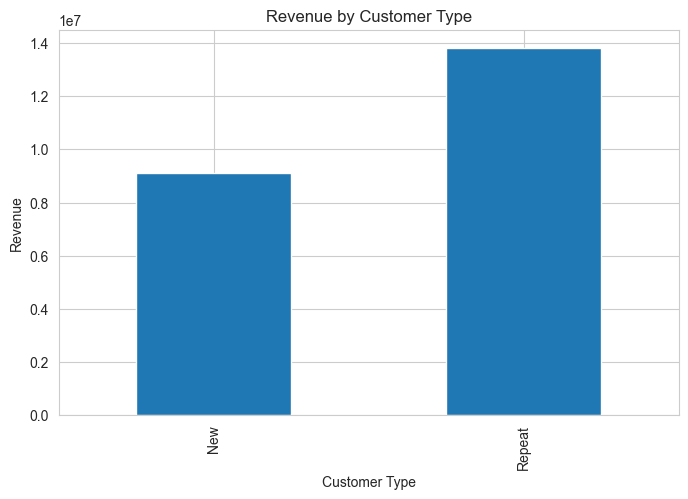

In [20]:
customer_revenue.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Revenue")

plt.show()